
Pesos sazonais por ciclo:
c1=0.4944, c2=0.4811, c3=0.0134, c4=0.0111

Parâmetros do padronizador:
médias [T, U, LIRAa] = [27.82068182 71.40136364  2.85833333]
desvios [T, U, LIRAa] = [1.11373532 7.00759348 1.8719234 ]
epoch    1 | MSE=3.744836 | beta∈[5.549e-01,6.324e-01]
epoch  100 | MSE=3.642659 | beta∈[4.814e-01,6.050e-01]
epoch  200 | MSE=3.550162 | beta∈[4.032e-01,6.098e-01]
epoch  300 | MSE=3.464021 | beta∈[3.327e-01,6.479e-01]
epoch  400 | MSE=3.383804 | beta∈[2.713e-01,6.955e-01]
epoch  500 | MSE=3.310462 | beta∈[2.200e-01,7.534e-01]
epoch  600 | MSE=3.245618 | beta∈[1.792e-01,8.207e-01]
epoch  700 | MSE=3.190685 | beta∈[1.481e-01,8.948e-01]
epoch  800 | MSE=3.146038 | beta∈[1.253e-01,9.712e-01]
epoch  900 | MSE=3.110875 | beta∈[1.088e-01,1.045e+00]
epoch 1000 | MSE=3.083627 | beta∈[9.704e-02,1.114e+00]
epoch 1100 | MSE=3.062534 | beta∈[8.853e-02,1.176e+00]
epoch 1200 | MSE=3.046017 | beta∈[8.229e-02,1.230e+00]
epoch 1300 | MSE=3.032796 | beta∈[7.764e-02,1.277e+00]
epoch 1400 

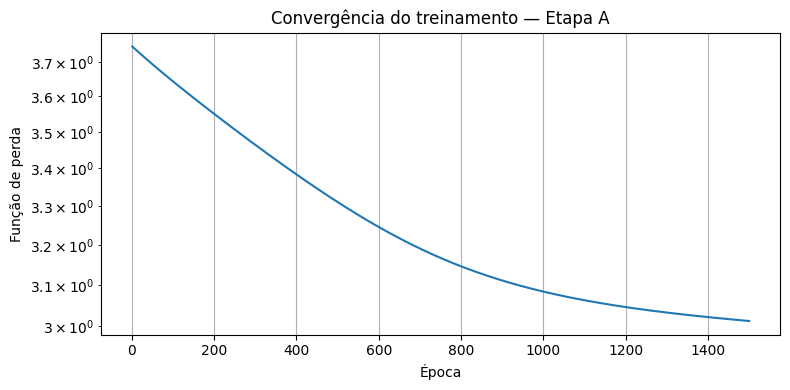

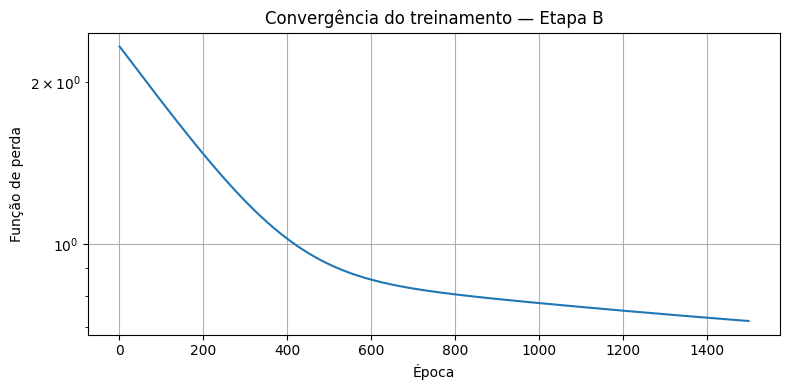

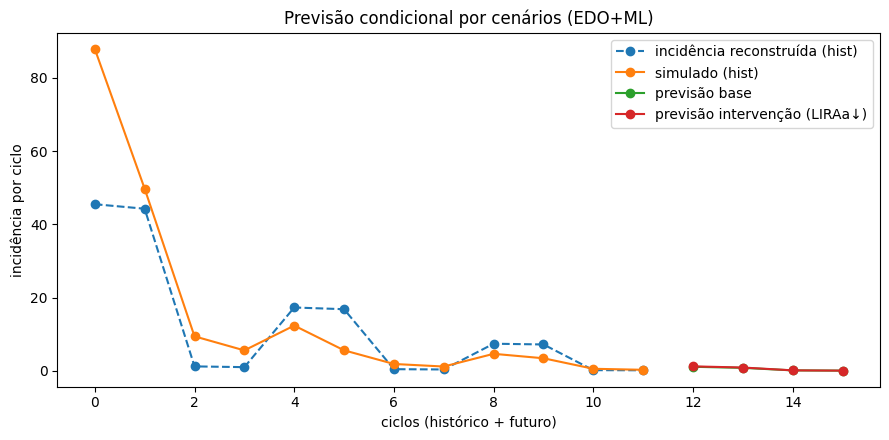

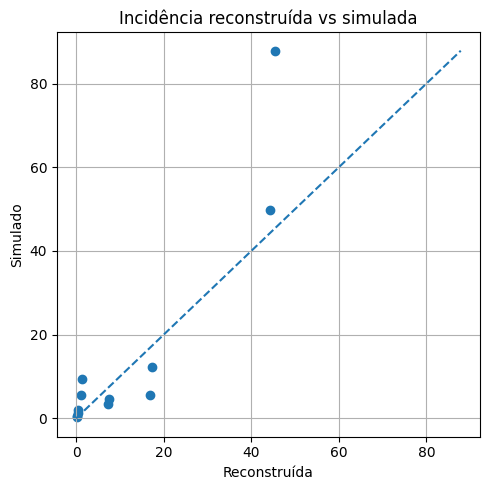

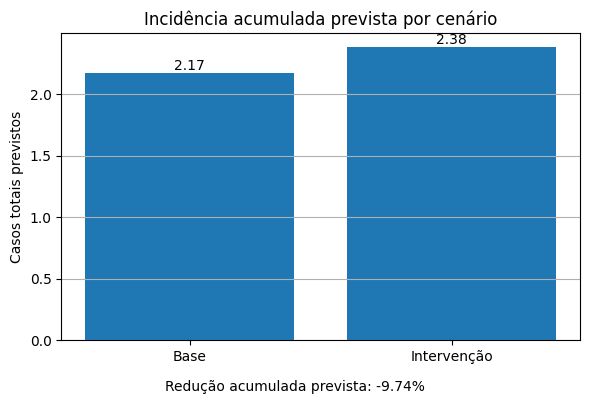

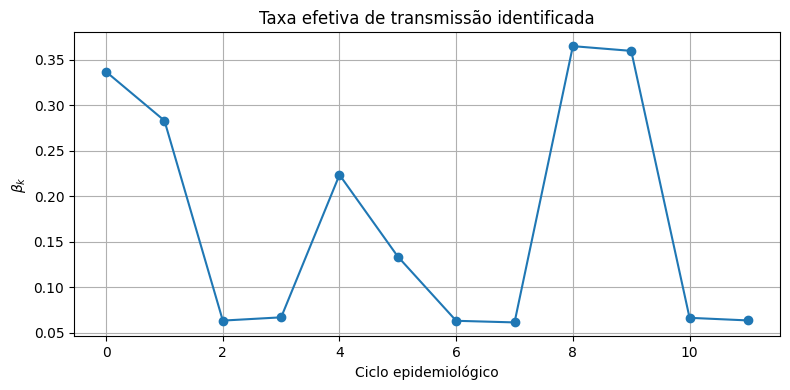

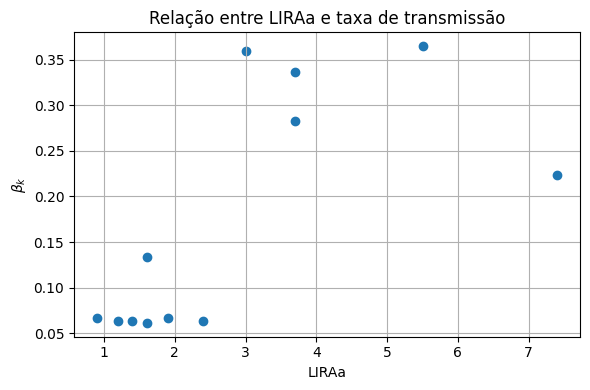

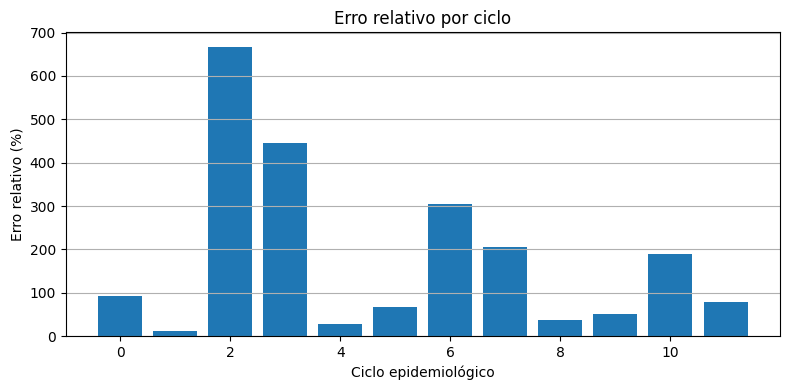

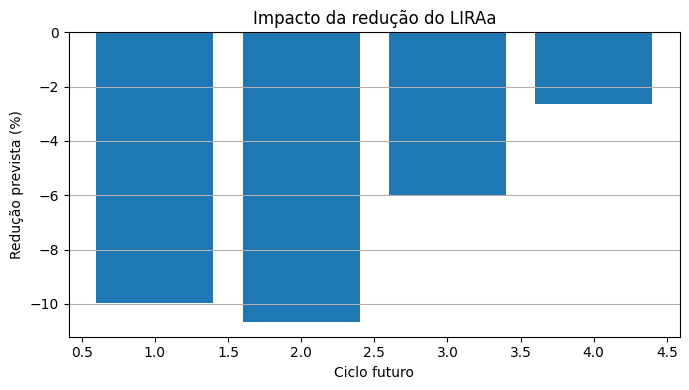

In [ ]:
# ============================================================
# VERSÃO CORRIGIDA — AJUSTES METODOLÓGICOS 2, 3 E 4
#
# 2) Escala temporal: tempo em meses; cada ciclo = 3 meses (dt=3.0), h=0.1 mês.
# 3) LIRAa: ausente na Etapa A -> NaN -> 0 na escala padronizada;
#    valores reais padronizados com média/desvio dos 12 levantamentos de 2023-2025.
# ============================================================

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.set_default_dtype(torch.float64)

# ============================================================
# 0) Normalização
# ============================================================

class StandardScaler:
    """
    Padronizador usado nas duas etapas.

    Regra para o LIRAa:
    - na Etapa A, a informação entomológica está ausente e é representada por NaN;
    - após a transformação, valores ausentes são mapeados para 0.0 na escala padronizada;
    - na Etapa B, os valores reais de LIRAa são padronizados normalmente.
    """
    def __init__(self):
        self.mean_ = None
        self.std_ = None

    def fit(self, X: np.ndarray):
        X = np.asarray(X, dtype=float)
        self.mean_ = np.nanmean(X, axis=0, keepdims=True)
        std = np.nanstd(X, axis=0, keepdims=True)
        self.std_ = np.where(np.isfinite(std) & (std >= 1e-8), std, 1.0)
        return self

    def transform(self, X: np.ndarray):
        X = np.asarray(X, dtype=float)
        Z = (X - self.mean_) / self.std_
        Z = np.where(np.isfinite(Z), Z, 0.0)
        return Z

    def fit_transform(self, X: np.ndarray):
        return self.fit(X).transform(X)


def build_two_stage_scaler(df_long: pd.DataFrame):
    """
    Constrói um único padronizador para as duas etapas.

    Temperatura e umidade: média/desvio da série longa 2015-2025.
    LIRAa: média/desvio dos 12 valores reais disponíveis em 2023-2025.
    """
    T = df_long["Tbar"].to_numpy(dtype=float)
    U = df_long["Ubar"].to_numpy(dtype=float)
    liraa_dict = get_liraa_real()
    L = np.array([value for values in liraa_dict.values() for value in values], dtype=float)

    mean = np.array([[T.mean(), U.mean(), L.mean()]], dtype=float)
    std = np.array([[T.std(), U.std(), L.std()]], dtype=float)
    std = np.where(std >= 1e-8, std, 1.0)

    scaler = StandardScaler()
    scaler.mean_ = mean
    scaler.std_ = std
    return scaler


# ============================================================
# 1) Modelo SEIR–SI
# ============================================================

def rhs_seir_si_torch(x, beta, mu_v, beta_v, sigma, gamma, Nh, Nv):
    Sh, Eh, Ih, Rh, Sv, Iv = x

    lam_h = beta * (Iv / Nv)
    lam_v = beta_v * (Ih / Nh)

    dSh = -lam_h * Sh
    dEh = lam_h * Sh - sigma * Eh
    dIh = sigma * Eh - gamma * Ih
    dRh = gamma * Ih

    dSv = mu_v * Nv - lam_v * Sv - mu_v * Sv
    dIv = lam_v * Sv - mu_v * Iv

    return torch.stack([dSh, dEh, dIh, dRh, dSv, dIv])


def enforce_mass_torch(x, Nh, Nv):
    Sh, Eh, Ih, Rh, Sv, Iv = x

    sum_h = torch.clamp(Sh + Eh + Ih + Rh, min=1e-12)
    sum_v = torch.clamp(Sv + Iv, min=1e-12)

    factor_h = Nh / sum_h
    factor_v = Nv / sum_v

    Sh, Eh, Ih, Rh = Sh * factor_h, Eh * factor_h, Ih * factor_h, Rh * factor_h
    Sv, Iv = Sv * factor_v, Iv * factor_v

    return torch.stack([Sh, Eh, Ih, Rh, Sv, Iv])


def integrate_one_window_and_incidence(
    x0, beta_k, mu_k, Nv_k,
    Nh, beta_v, sigma, gamma,
    dt=3.0, h=0.1
):
    """
    Integra um ciclo e aproxima:
        y_k ≈ ∫ sigma * Eh(t) dt
    """
    n_steps = int(round(dt / h))
    x = x0
    y_inc = torch.tensor(0.0, dtype=torch.float64)

    for _ in range(n_steps):
        y_inc = y_inc + (sigma * x[1]) * h
        dx = rhs_seir_si_torch(x, beta_k, mu_k, beta_v, sigma, gamma, Nh, Nv_k)
        x = x + h * dx
        x = torch.clamp(x, min=0.0)
        x = enforce_mass_torch(x, Nh, Nv_k)

    return x, y_inc


# ============================================================
# 2) Rede neural beta_k = g_theta(z_k)
# ============================================================

class BetaNet(nn.Module):
    def __init__(self, in_dim=3, hidden=12, beta_min=0.05):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.Tanh(),
            nn.Linear(hidden, hidden),
            nn.Tanh(),
            nn.Linear(hidden, 1),
        )
        self.softplus = nn.Softplus(beta=2.0)
        self.beta_min = beta_min

    def forward(self, z):
        raw = self.net(z);
        beta = self.beta_min + self.softplus(raw)
        return beta.squeeze(-1)

# ============================================================
# 3) Simulação por ciclos
# ============================================================

def simulate_trajectory_and_incidence(
    Z_scaled_torch,
    Tbar, Ubar, LIRAa,
    model_beta: nn.Module,
    x0: torch.Tensor,
    Nh=10_000.0,
    Nv_bar=12_000.0,
    beta_v=0.25,
    sigma=30/5,
    gamma=30/7,
    mu0=0.30,
    delta=0.03,
    dt=3.0,
    h=0.1
):
    M = Z_scaled_torch.shape[0]

    Nh_t = torch.tensor(float(Nh))
    Nv_t = torch.tensor(float(Nv_bar)) # Define Nv_t here
    # O LIRAa permanece como covariável da RNA, mas não altera diretamente Nv.
    # A população vetorial de referência é mantida constante em todos os ciclos.
    beta_v_t = torch.tensor(float(beta_v))
    sigma_t = torch.tensor(float(sigma))
    gamma_t = torch.tensor(float(gamma))

    mu_k = mu0 * np.exp(-delta * np.asarray(Tbar, dtype=float))
    mu_k_t = torch.tensor(mu_k, dtype=torch.float64)

    beta_k = model_beta(Z_scaled_torch)

    x = x0.clone()
    x = torch.clamp(x, min=0.0)
    x = enforce_mass_torch(x, Nh_t, Nv_t)

    X_end = []
    y_inc = []

    for k in range(M):
        x, yk = integrate_one_window_and_incidence(
            x0=x,
            beta_k=beta_k[k],
            mu_k=mu_k_t[k],
            Nv_k=Nv_t,
            Nh=Nh_t,
            beta_v=beta_v_t,
            sigma=sigma_t,
            gamma=gamma_t,
            dt=dt,
            h=h
        )
        X_end.append(x)
        y_inc.append(yk)

    return torch.stack(X_end), torch.stack(y_inc), beta_k


# ============================================================
# 4) Treinamento
# ============================================================

def train_model(
    df_hist: pd.DataFrame,
    model=None,
    scaler=None,
    x0_custom=None,
    epochs=1500,
    lr=1e-4,
    weight_decay=1e-6,
    print_every=100,
    Nh=10_000.0,
    Nv_bar=12_000.0,
    beta_v=0.25,
    sigma=30/5,
    gamma=30/7,
    mu0=0.30,
    delta=0.03,
    dt=3.0,
    h=0.1
):
    Z = df_hist[["Tbar", "Ubar", "LIRAa"]].values.astype(float)
    y_obs = df_hist["y_obs"].values.astype(float)

    if scaler is None:
        scaler = StandardScaler()
        Zs = scaler.fit_transform(Z)
    else:
        Zs = scaler.transform(Z)

    z_t = torch.tensor(Zs, dtype=torch.float64)
    y_t = torch.tensor(y_obs, dtype=torch.float64)

    if model is None:
        model = BetaNet(in_dim=3, hidden=12)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    if x0_custom is None:
        Ih0 = max(5.0, 0.1 * float(y_obs[0]))
        Eh0 = max(2.0, 0.5 * Ih0)
        Rh0 = 0.0
        Sh0 = Nh - Eh0 - Ih0 - Rh0

        Iv0 = 0.01 * Nv_bar
        Sv0 = Nv_bar - Iv0

        x0 = torch.tensor([Sh0, Eh0, Ih0, Rh0, Sv0, Iv0], dtype=torch.float64)
    else:
        x0 = x0_custom.clone().detach().to(dtype=torch.float64)

    loss_history = []

    for ep in range(1, epochs + 1):
        optimizer.zero_grad()

        X_end, y_sim, beta_k = simulate_trajectory_and_incidence(
            Z_scaled_torch=z_t,
            Tbar=df_hist["Tbar"].values,
            Ubar=df_hist["Ubar"].values,
            LIRAa=df_hist["LIRAa"].values,
            model_beta=model,
            x0=x0,
            Nh=Nh,
            Nv_bar=Nv_bar,
            beta_v=beta_v,
            sigma=sigma,
            gamma=gamma,
            mu0=mu0,
            delta=delta,
            dt=dt,
            h=h
        )
        weights = 1.0 + 2.0 * (y_t / torch.clamp(torch.max(y_t), min=1e-12))
        loss = torch.mean(
            weights * (torch.log1p(y_sim) - torch.log1p(y_t)) ** 2)
        loss_history.append(float(loss.item()))
        loss.backward()
        optimizer.step()

        if ep % print_every == 0 or ep == 1:
            print(
                f"epoch {ep:4d} | "
                f"MSE={loss.item():.6f} | "
                f"beta∈[{beta_k.min().item():.3e},{beta_k.max().item():.3e}]"
            )

    with torch.no_grad():
        X_end, y_sim, beta_k = simulate_trajectory_and_incidence(
            Z_scaled_torch=z_t,
            Tbar=df_hist["Tbar"].values,
            Ubar=df_hist["Ubar"].values,
            LIRAa=df_hist["LIRAa"].values,
            model_beta=model,
            x0=x0,
            Nh=Nh,
            Nv_bar=Nv_bar,
            beta_v=beta_v,
            sigma=sigma,
            gamma=gamma,
            mu0=mu0,
            delta=delta,
            dt=dt,
            h=h
        )

    xM_hat = X_end[-1].clone()

    out = df_hist.copy()
    out["y_sim"] = y_sim.detach().numpy()
    out["beta_k"] = beta_k.detach().numpy()

    return model, scaler, xM_hat, out, loss_history


# ============================================================
# 5) Previsão condicional
# ============================================================

def forecast_conditional(
    model: nn.Module,
    scaler: StandardScaler,
    x_last: torch.Tensor,
    df_scenario: pd.DataFrame,
    Nh=10_000.0,
    Nv_bar=12_000.0,
    beta_v=0.25,
    sigma=30/5,
    gamma=30/7,
    mu0=0.30,
    delta=0.03,
    dt=3.0,
    h=0.1
):
    Zf = df_scenario[["Tbar", "Ubar", "LIRAa"]].values.astype(float)
    Zfs = scaler.transform(Zf)
    zf_t = torch.tensor(Zfs, dtype=torch.float64)

    with torch.no_grad():
        X_end, y_hat, beta_hat = simulate_trajectory_and_incidence(
            Z_scaled_torch=zf_t,
            Tbar=df_scenario["Tbar"].values,
            Ubar=df_scenario["Ubar"].values,
            LIRAa=df_scenario["LIRAa"].values,
            model_beta=model,
            x0=x_last,
            Nh=Nh,
            Nv_bar=Nv_bar,
            beta_v=beta_v,
            sigma=sigma,
            gamma=gamma,
            mu0=mu0,
            delta=delta,
            dt=dt,
            h=h
        )

    out = df_scenario.copy()
    out["y_hat"] = y_hat.numpy()
    out["beta_hat"] = beta_hat.numpy()

    return out, X_end[-1].clone()


# ============================================================
# 6) Cenários
# ============================================================

def make_scenario_seasonal_repeat(df_hist: pd.DataFrame, H=4):
    return df_hist[["Tbar", "Ubar", "LIRAa"]].tail(H).copy().reset_index(drop=True)


def make_scenario_intervention(df_base: pd.DataFrame, liraa_factor=0.7):
    df_int = df_base.copy()
    df_int["LIRAa"] = df_int["LIRAa"] * float(liraa_factor)
    return df_int


def plot_compare(history_out: pd.DataFrame, base_fc: pd.DataFrame, int_fc: pd.DataFrame,
                 title="Previsão condicional por cenários (EDO+ML)"):
    plt.figure(figsize=(9, 4.5))

    plt.plot(np.arange(len(history_out)), history_out["y_obs"], "o--", label="incidência reconstruída (hist)")
    plt.plot(np.arange(len(history_out)), history_out["y_sim"], "o-", label="simulado (hist)")

    k0 = len(history_out)
    plt.plot(np.arange(k0, k0 + len(base_fc)), base_fc["y_hat"], "o-", label="previsão base")
    plt.plot(np.arange(k0, k0 + len(int_fc)), int_fc["y_hat"], "o-", label="previsão intervenção (LIRAa↓)")

    plt.xlabel("ciclos (histórico + futuro)")
    plt.ylabel("incidência por ciclo")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


# ============================================================
# 6.1) Diagnóstico do ajuste e tabelas automáticas
# ============================================================

def plot_loss_history(loss_history, title="Convergência do treinamento"):
    """Plota a evolução do funcional de custo ao longo das épocas."""
    if not loss_history:
        raise ValueError("loss_history está vazio.")
    plt.figure(figsize=(8, 4))
    plt.plot(np.arange(1, len(loss_history) + 1), loss_history)
    plt.xlabel("Época")
    plt.ylabel("Função de perda")
    plt.title(title)
    plt.yscale("log")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


def calculate_regression_metrics(y_obs, y_sim):
    """Calcula RMSE, MAE e R²."""
    y_obs = np.asarray(y_obs, dtype=float)
    y_sim = np.asarray(y_sim, dtype=float)
    if y_obs.shape != y_sim.shape:
        raise ValueError("y_obs e y_sim devem possuir a mesma dimensão.")
    residual = y_obs - y_sim
    rmse = np.sqrt(np.mean(residual ** 2))
    mae = np.mean(np.abs(residual))
    ss_res = np.sum(residual ** 2)
    ss_tot = np.sum((y_obs - np.mean(y_obs)) ** 2)
    r2 = np.nan if ss_tot <= 1e-12 else 1.0 - ss_res / ss_tot
    return {"RMSE": float(rmse), "MAE": float(mae), "R2": float(r2)}


def build_fit_table(out_df: pd.DataFrame, relative_error_floor=1.0):
    """Cria tabela com observado, simulado, erro absoluto e erro relativo."""
    table = out_df.copy()
    table["erro_absoluto"] = np.abs(table["y_obs"] - table["y_sim"])
    denominator = np.maximum(np.abs(table["y_obs"]), float(relative_error_floor))
    table["erro_relativo_pct"] = 100.0 * table["erro_absoluto"] / denominator
    cols = [c for c in ["ano", "ciclo", "cycle_idx", "y_obs", "y_sim",
                           "erro_absoluto", "erro_relativo_pct", "beta_k", "LIRAa"]
            if c in table.columns]
    return table[cols]


def build_metrics_table(out_df: pd.DataFrame, stage_name="Modelo"):
    metrics = calculate_regression_metrics(out_df["y_obs"], out_df["y_sim"])
    return pd.DataFrame([{ "etapa": stage_name, **metrics }])


def compare_scenario_totals(base_fc: pd.DataFrame, int_fc: pd.DataFrame):
    total_base = float(base_fc["y_hat"].sum())
    total_intervention = float(int_fc["y_hat"].sum())
    difference = total_base - total_intervention
    reduction_pct = 100.0 * difference / total_base if abs(total_base) > 1e-12 else np.nan
    totals = pd.DataFrame({
        "cenario": ["Base", "Intervenção"],
        "casos_totais_previstos": [total_base, total_intervention],
    })
    summary = {"diferenca_absoluta": difference, "reducao_percentual": reduction_pct}
    return totals, summary


def plot_scenario_totals(base_fc: pd.DataFrame, int_fc: pd.DataFrame):
    totals_df, comparison = compare_scenario_totals(base_fc, int_fc)
    plt.figure(figsize=(6, 4))
    bars = plt.bar(totals_df["cenario"], totals_df["casos_totais_previstos"])
    plt.ylabel("Casos totais previstos")
    plt.title("Incidência acumulada prevista por cenário")
    plt.grid(axis="y")
    for bar, value in zip(bars, totals_df["casos_totais_previstos"]):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f"{value:.2f}",
                 ha="center", va="bottom")
    if np.isfinite(comparison["reducao_percentual"]):
        plt.figtext(0.5, 0.01,
                    f"Redução acumulada prevista: {comparison['reducao_percentual']:.2f}%",
                    ha="center")
    plt.tight_layout(rect=(0, 0.04, 1, 1))
    plt.show()


# ============================================================
# 7) Dados SINAN
# ============================================================
def get_climate_real():
    return {
        2015: {
            "Tbar": [26.79, 26.92, 28.00, 29.77],
            "Ubar": [72.02, 75.46, 65.86, 60.81],
        },
        2016: {
            "Tbar": [27.06, 27.32, 28.36, 29.51],
            "Ubar": [72.56, 74.50, 64.99, 63.81],
        },
        2017: {
            "Tbar": [26.27, 26.41, 28.20, 29.15],
            "Ubar": [82.09, 79.55, 63.51, 63.35],
        },
        2018: {
            "Tbar": [26.52, 26.22, 28.24, 28.82],
            "Ubar": [79.41, 82.93, 66.15, 70.52],
        },
        2019: {
            "Tbar": [26.49, 26.87, 28.54, 29.26],
            "Ubar": [81.21, 76.44, 67.21, 65.56],
        },
        2020: {
            "Tbar": [26.67, 26.90, 28.68, 29.03],
            "Ubar": [80.56, 77.09, 63.94, 67.21],
        },
        2021: {
            "Tbar": [26.67, 26.99, 27.90, 28.73],
            "Ubar": [78.26, 77.92, 68.95, 71.03],
        },
        2022: {
            "Tbar": [26.66, 26.94, 28.20, 28.81],
            "Ubar": [77.82, 78.57, 67.06, 68.64],
        },
        2023: {
            "Tbar": [26.80, 27.02, 28.51, 29.57],
            "Ubar": [78.83, 77.44, 63.11, 63.28],
        },
        2024: {
            "Tbar": [27.02, 27.73, 29.14, 29.84],
            "Ubar": [76.99, 71.16, 61.35, 59.47],
        },
        2025: {
            "Tbar": [26.72, 26.81, 28.47, 29.58],
            "Ubar": [80.27, 78.85, 64.17, 61.75],
        },
    }

def get_annual_cases_sinan():
    return {
        2015: 58,
        2016: 203,
        2017: 40,
        2018: 1,
        2019: 6,
        2020: 7,
        2021: 3,
        2022: 15,
        2023: 92,
        2024: 35,
        2025: 15,
    }


def get_weekly_aggregated_counts():
    return {
        1: 4, 2: 5, 3: 4, 4: 6, 5: 5, 6: 7, 7: 9, 8: 21, 9: 27, 10: 33,
        11: 31, 12: 38, 13: 32, 14: 41, 15: 63, 16: 28, 17: 22, 18: 29,
        19: 13, 20: 10, 21: 2, 22: 6, 23: 1, 25: 1, 29: 1, 31: 1, 32: 1,
        35: 1, 37: 1, 38: 1, 41: 1, 44: 1, 48: 2, 50: 1,
    }


def seasonal_cycle_weights_from_weekly():
    weekly_data = get_weekly_aggregated_counts()

    weeks = np.arange(1, 54)
    counts = np.array([weekly_data.get(w, 0.0) for w in weeks], dtype=float)

    c1 = counts[(weeks >= 1) & (weeks <= 13)].sum()
    c2 = counts[(weeks >= 14) & (weeks <= 26)].sum()
    c3 = counts[(weeks >= 27) & (weeks <= 39)].sum()
    c4 = counts[(weeks >= 40) & (weeks <= 53)].sum()

    seasonal = np.array([c1, c2, c3, c4], dtype=float)
    weights = seasonal / seasonal.sum()
    return weights


def get_liraa_real():
    return {
        2023: [3.7, 3.7, 2.4, 0.9],
        2024: [7.4, 1.6, 1.2, 1.6],
        2025: [5.5, 3.0, 1.9, 1.4],
    }


# ============================================================
# 8) Datasets
# ============================================================

def build_long_df_2015_2025():
    annual_cases = get_annual_cases_sinan()
    weights = seasonal_cycle_weights_from_weekly()
    climate = get_climate_real()

    rows = []
    idx = 0

    for year, Y in annual_cases.items():
        y_cycles = Y * weights

        Tbar_year = np.array(climate[year]["Tbar"], dtype=float)
        Ubar_year = np.array(climate[year]["Ubar"], dtype=float)

        for cycle in range(1, 5):
            rows.append({
                "ano": year,
                "cycle_idx": idx,
                "ciclo": cycle,
                "Tbar": Tbar_year[cycle - 1],
                "Ubar": Ubar_year[cycle - 1],
                "LIRAa": np.nan,
                "y_obs": y_cycles[cycle - 1],
            })
            idx += 1

    return pd.DataFrame(rows)


def inject_liraa_real_2023_2025(df):
    df = df.copy()
    liraa_dict = get_liraa_real()

    for year, vals in liraa_dict.items():
        for cycle in range(1, 5):
            mask = (df["ano"] == year) & (df["ciclo"] == cycle)
            df.loc[mask, "LIRAa"] = vals[cycle - 1]

    return df


def build_short_df_2023_2025_from_long(df_long):
    return df_long[df_long["ano"].isin([2023, 2024, 2025])].copy().reset_index(drop=True)


# ============================================================
# 9) Execução principal
# ============================================================
def reinject_infection_state(
    x,
    Nh=10_000.0,
    Nv_bar=12_000.0,
    Eh_min=10.0,
    Ih_min=8.0,
    Iv_min=120.0
):
    """
    Reintroduz uma quantidade mínima de infecção antes da Etapa B,
    evitando que o sistema comece em estado epidemiologicamente extinto.
    """

    x_new = x.clone().detach().to(dtype=torch.float64)

    Rh = x_new[3]

    Eh = torch.tensor(max(float(x_new[1]), Eh_min), dtype=torch.float64)
    Ih = torch.tensor(max(float(x_new[2]), Ih_min), dtype=torch.float64)
    Iv = torch.tensor(max(float(x_new[5]), Iv_min), dtype=torch.float64)

    Sh = torch.tensor(float(Nh), dtype=torch.float64) - Eh - Ih - Rh
    Sv = torch.tensor(float(Nv_bar), dtype=torch.float64) - Iv

    x_new = torch.stack([Sh, Eh, Ih, Rh, Sv, Iv])
    x_new = torch.clamp(x_new, min=0.0)

    return enforce_mass_torch(
        x_new,
        torch.tensor(float(Nh), dtype=torch.float64),
        torch.tensor(float(Nv_bar), dtype=torch.float64)
    )
def plot_beta_temporal(out_short):
    plt.figure(figsize=(8, 4))
    plt.plot(np.arange(len(out_short)), out_short["beta_k"], "o-")
    plt.xlabel("Ciclo epidemiológico")
    plt.ylabel(r"$\beta_k$")
    plt.title("Taxa efetiva de transmissão identificada")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


def plot_liraa_vs_beta(out_short):
    plt.figure(figsize=(6, 4))
    plt.scatter(out_short["LIRAa"], out_short["beta_k"])
    plt.xlabel("LIRAa")
    plt.ylabel(r"$\beta_k$")
    plt.title("Relação entre LIRAa e taxa de transmissão")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


def plot_obs_vs_sim(out_short):
    plt.figure(figsize=(5, 5))
    plt.scatter(out_short["y_obs"], out_short["y_sim"])

    m = max(out_short["y_obs"].max(), out_short["y_sim"].max())
    plt.plot([0, m], [0, m], "--")

    plt.xlabel("Reconstruída")
    plt.ylabel("Simulado")
    plt.title("Incidência reconstruída vs simulada")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


def plot_erro_relativo(out_short):
    eps = 1e-12
    erro_rel = (
        np.abs(out_short["y_obs"] - out_short["y_sim"])
        / np.maximum(out_short["y_obs"], eps)
    ) * 100

    plt.figure(figsize=(8, 4))
    plt.bar(np.arange(len(erro_rel)), erro_rel)
    plt.xlabel("Ciclo epidemiológico")
    plt.ylabel("Erro relativo (%)")
    plt.title("Erro relativo por ciclo")
    plt.grid(axis="y")
    plt.tight_layout()
    plt.show()


def plot_reducao_intervencao(base_fc, int_fc):
    eps = 1e-12
    reducao = (
        (base_fc["y_hat"] - int_fc["y_hat"])
        / np.maximum(base_fc["y_hat"], eps)
    ) * 100

    plt.figure(figsize=(7, 4))
    plt.bar(np.arange(1, len(reducao) + 1), reducao)
    plt.xlabel("Ciclo futuro")
    plt.ylabel("Redução prevista (%)")
    plt.title("Impacto da redução do LIRAa")
    plt.grid(axis="y")
    plt.tight_layout()
    plt.show()





if __name__ == "__main__":

    # -------------------------
    # ETAPA A: calibração longa
    # -------------------------
    df_long = build_long_df_2015_2025()

    print("\nPesos sazonais por ciclo:")
    w = seasonal_cycle_weights_from_weekly()
    print(f"c1={w[0]:.4f}, c2={w[1]:.4f}, c3={w[2]:.4f}, c4={w[3]:.4f}")

    # Um único sistema de padronização é definido antes da Etapa A.
    # Na Etapa A, LIRAa ausente = NaN -> 0 na escala padronizada.
    # Na Etapa B, os valores reais são padronizados com a mesma escala.
    scaler = build_two_stage_scaler(df_long)

    print("\nParâmetros do padronizador:")
    print("médias [T, U, LIRAa] =", scaler.mean_.ravel())
    print("desvios [T, U, LIRAa] =", scaler.std_.ravel())

    model, scaler, xA_hat, out_long, loss_A = train_model(
        df_long,
        model=None,
        scaler=scaler,
        epochs=1500,
        lr=1e-4,
        weight_decay=1e-6,
        print_every=100,
        Nh=10_000.0,
        Nv_bar=12_000.0,
        beta_v=0.25,
        sigma=30/5,
        gamma=30/7,
        mu0=0.30,
        delta=0.03,
        dt=3.0,
        h=0.1
    )

    print("\nResumo ETAPA A:")
    print(out_long[["ano", "ciclo", "y_obs", "y_sim", "beta_k"]].tail(12))

    # -------------------------
    # ETAPA B: refino com LIRAa
    # -------------------------
    df_long_with_liraa = inject_liraa_real_2023_2025(df_long)
    df_short = build_short_df_2023_2025_from_long(df_long_with_liraa)
    x0_initial = reinject_infection_state(
        xA_hat,
        Nh=10_000.0,
        Nv_bar=12_000.0,
        Eh_min=10.0,
        Ih_min=8.0,
        Iv_min=120.0
    )
    model, scaler, xM_hat, out_short, loss_B = train_model(
        df_short,
        model=model,
        scaler=scaler,
        x0_custom=x0_initial,
        epochs=1500,
        lr=1e-4,
        weight_decay=1e-6,
        print_every=100,
        Nh=10_000.0,
        Nv_bar=12_000.0,
        beta_v=0.25,
        sigma=30/5,
        gamma=30/7,
        mu0=0.30,
        delta=0.03,
        dt=3.0,
        h=0.1
    )

    print("\nResumo ETAPA B:")
    print(out_short[["ano", "ciclo", "y_obs", "y_sim", "beta_k", "LIRAa"]])

    # -------------------------
    # Previsão por cenários
    # -------------------------
    H = 4
    df_base = make_scenario_seasonal_repeat(df_short, H=H)
    df_int = make_scenario_intervention(df_base, liraa_factor=0.7)

    base_fc, _ = forecast_conditional(
        model, scaler, xM_hat, df_base,
        Nh=10_000.0,
        Nv_bar=12_000.0,
        beta_v=0.25,
        sigma=30/5,
        gamma=30/7,
        mu0=0.30,
        delta=0.03,
        dt=3.0,
        h=0.1
    )

    int_fc, _ = forecast_conditional(
        model, scaler, xM_hat, df_int,
        Nh=10_000.0,
        Nv_bar=12_000.0,
        beta_v=0.25,
        sigma=30/5,
        gamma=30/7,
        mu0=0.30,
        delta=0.03,
        dt=3.0,
        h=0.1
    )

    print("\nPrevisão base:")
    print(base_fc.assign(scenario="base"))

    print("\nPrevisão intervenção:")
    print(int_fc.assign(scenario="interv"))

    # -------------------------
    # Métricas e tabelas automáticas
    # -------------------------
    metrics_A = build_metrics_table(out_long, stage_name="Etapa A")
    metrics_B = build_metrics_table(out_short, stage_name="Etapa B")
    metrics_all = pd.concat([metrics_A, metrics_B], ignore_index=True)

    fit_table_A = build_fit_table(out_long)
    fit_table_B = build_fit_table(out_short)
    scenario_totals, scenario_comparison = compare_scenario_totals(base_fc, int_fc)

    print("\nMétricas globais de ajuste:")
    print(metrics_all.to_string(index=False))

    print("\nTabela automática de ajuste — ETAPA B:")
    print(fit_table_B.to_string(index=False))

    print("\nComparação acumulada dos cenários:")
    print(scenario_totals.to_string(index=False))
    print(f"Diferença absoluta prevista: {scenario_comparison['diferenca_absoluta']:.4f} casos")
    print(f"Redução percentual prevista: {scenario_comparison['reducao_percentual']:.4f}%")

    metrics_all.to_csv("metricas_ajuste.csv", index=False)
    fit_table_A.to_csv("tabela_ajuste_etapa_A.csv", index=False)
    fit_table_B.to_csv("tabela_ajuste_etapa_B.csv", index=False)
    scenario_totals.to_csv("comparacao_cenarios_totais.csv", index=False)

    plot_loss_history(loss_A, title="Convergência do treinamento — Etapa A")
    plot_loss_history(loss_B, title="Convergência do treinamento — Etapa B")
    plot_compare(out_short, base_fc, int_fc)
    plot_obs_vs_sim(out_short)
    plot_scenario_totals(base_fc, int_fc)

    # Gráficos diagnósticos já existentes
    plot_beta_temporal(out_short)
    plot_liraa_vs_beta(out_short)
    plot_erro_relativo(out_short)
    plot_reducao_intervencao(base_fc, int_fc)



Pesos sazonais por ciclo:
c1=0.4944, c2=0.4811, c3=0.0134, c4=0.0111

Parâmetros do padronizador:
médias [T, U, LIRAa] = [27.82068182 71.40136364  2.85833333]
desvios [T, U, LIRAa] = [1.11373532 7.00759348 1.8719234 ]
epoch    1 | MSE=3.608935 | beta∈[2.455e-01,3.269e-01]
epoch  100 | MSE=3.544052 | beta∈[2.842e-01,3.384e-01]
epoch  200 | MSE=3.494331 | beta∈[2.921e-01,3.493e-01]
epoch  300 | MSE=3.445946 | beta∈[2.792e-01,3.981e-01]
epoch  400 | MSE=3.392300 | beta∈[2.488e-01,4.563e-01]
epoch  500 | MSE=3.332864 | beta∈[2.128e-01,5.305e-01]
epoch  600 | MSE=3.269836 | beta∈[1.772e-01,6.245e-01]
epoch  700 | MSE=3.207478 | beta∈[1.450e-01,7.392e-01]
epoch  800 | MSE=3.151058 | beta∈[1.188e-01,8.700e-01]
epoch  900 | MSE=3.104588 | beta∈[9.939e-02,1.008e+00]
epoch 1000 | MSE=3.069231 | beta∈[8.594e-02,1.141e+00]
epoch 1100 | MSE=3.043613 | beta∈[7.699e-02,1.262e+00]
epoch 1200 | MSE=3.025246 | beta∈[7.113e-02,1.365e+00]
epoch 1300 | MSE=3.011732 | beta∈[6.727e-02,1.450e+00]
epoch 1400 

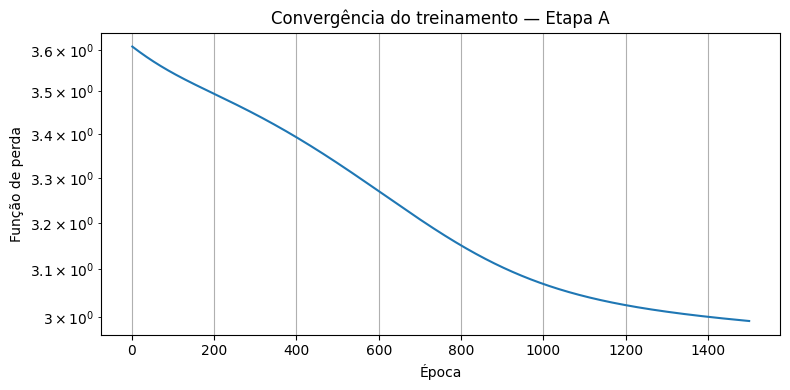

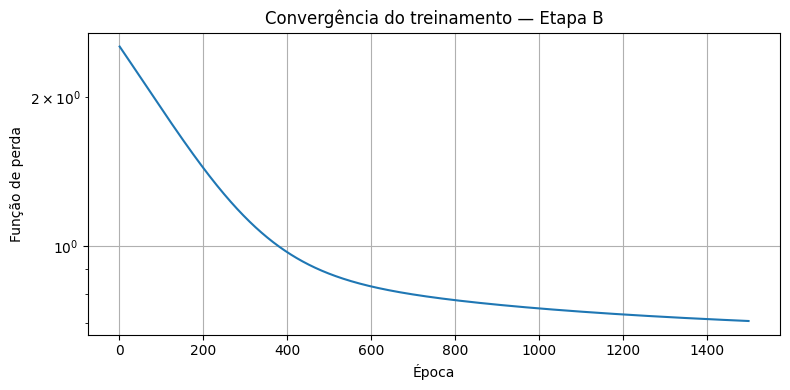

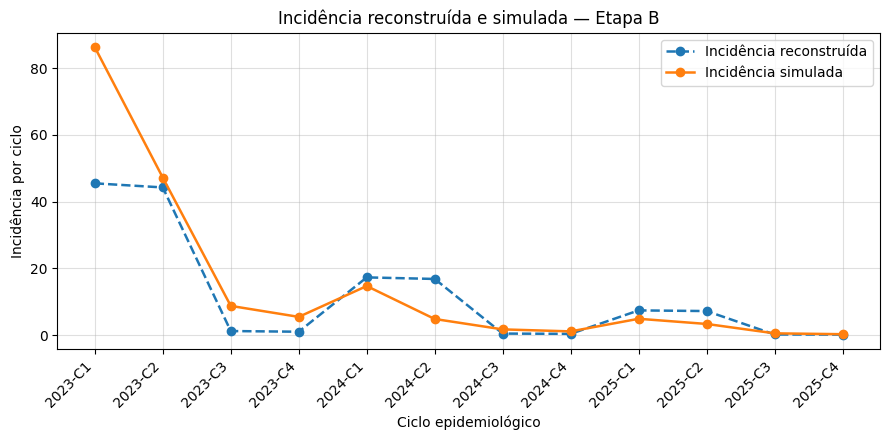

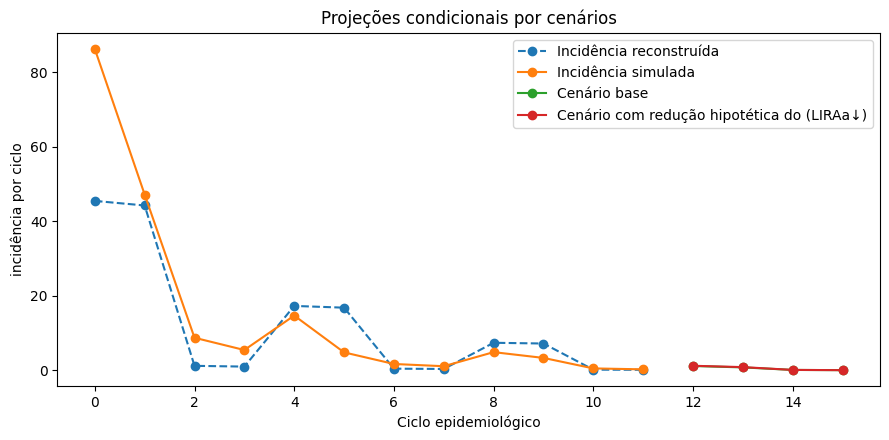

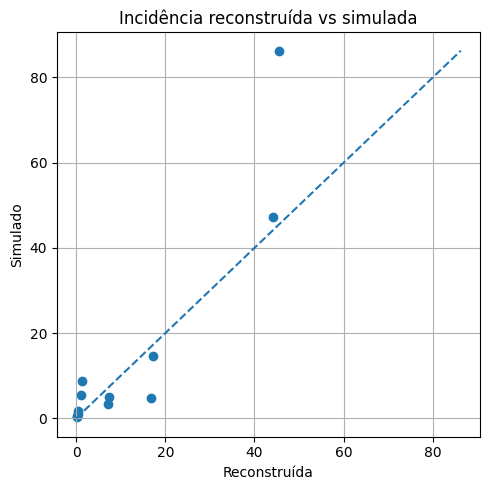

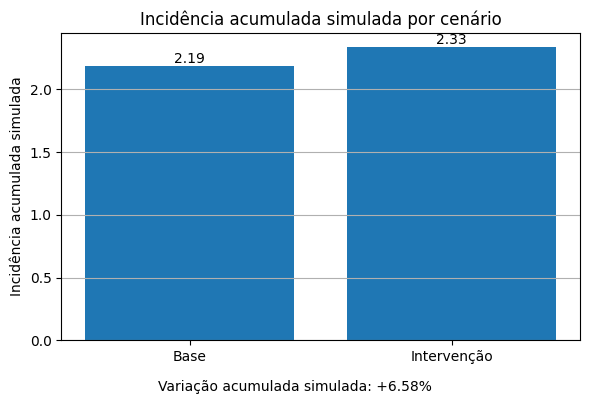

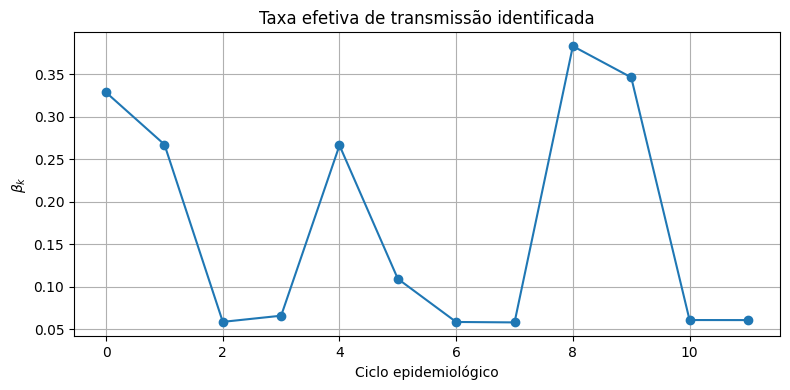

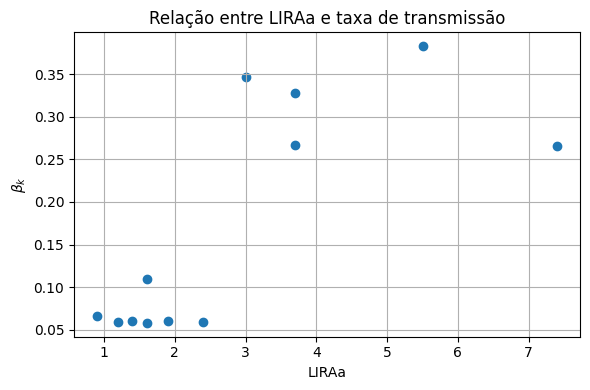

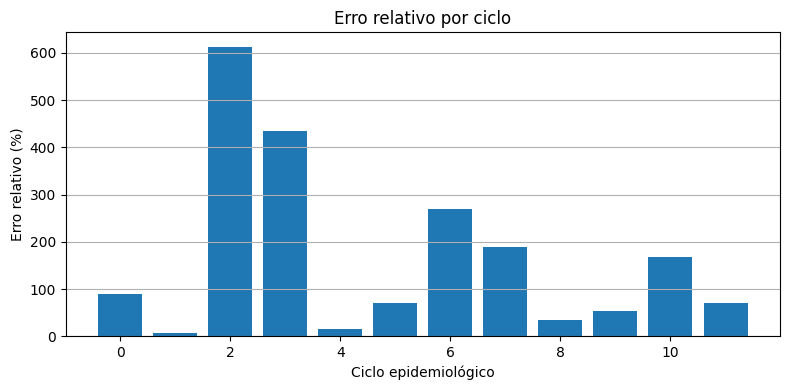

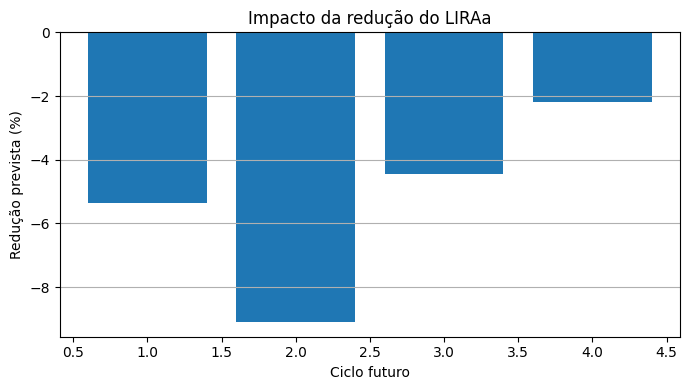

In [ ]:
# ============================================================
# VERSÃO CORRIGIDA — AJUSTES METODOLÓGICOS 2, 3 E 4
#
# 2) Escala temporal: tempo em meses; cada ciclo = 3 meses (dt=3.0), h=0.1 mês.
# 3) LIRAa: ausente na Etapa A -> NaN -> 0 na escala padronizada;
#    valores reais padronizados com média/desvio dos 12 levantamentos de 2023-2025.
# 4) Nv constante: removida a modulação Nv*(1+0.25*LIRAa).
# ============================================================

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import random

torch.set_default_dtype(torch.float64)
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
# ============================================================
# 0) Normalização
# ============================================================

class StandardScaler:
    """
    Padronizador usado nas duas etapas.

    Regra para o LIRAa:
    - na Etapa A, a informação entomológica está ausente e é representada por NaN;
    - após a transformação, valores ausentes são mapeados para 0.0 na escala padronizada;
    - na Etapa B, os valores reais de LIRAa são padronizados normalmente.
    """
    def __init__(self):
        self.mean_ = None
        self.std_ = None

    def fit(self, X: np.ndarray):
        X = np.asarray(X, dtype=float)
        self.mean_ = np.nanmean(X, axis=0, keepdims=True)
        std = np.nanstd(X, axis=0, keepdims=True)
        self.std_ = np.where(np.isfinite(std) & (std >= 1e-8), std, 1.0)
        return self

    def transform(self, X: np.ndarray):
        X = np.asarray(X, dtype=float)
        Z = (X - self.mean_) / self.std_
        Z = np.where(np.isfinite(Z), Z, 0.0)
        return Z

    def fit_transform(self, X: np.ndarray):
        return self.fit(X).transform(X)


def build_two_stage_scaler(df_long: pd.DataFrame):
    """
    Constrói um único padronizador para as duas etapas.

    Temperatura e umidade: média/desvio da série longa 2015-2025.
    LIRAa: média/desvio dos 12 valores reais disponíveis em 2023-2025.
    """
    T = df_long["Tbar"].to_numpy(dtype=float)
    U = df_long["Ubar"].to_numpy(dtype=float)
    liraa_dict = get_liraa_real()
    L = np.array([value for values in liraa_dict.values() for value in values], dtype=float)

    mean = np.array([[T.mean(), U.mean(), L.mean()]], dtype=float)
    std = np.array([[T.std(), U.std(), L.std()]], dtype=float)
    std = np.where(std >= 1e-8, std, 1.0)

    scaler = StandardScaler()
    scaler.mean_ = mean
    scaler.std_ = std
    return scaler


# ============================================================
# 1) Modelo SEIR–SI
# ============================================================

def rhs_seir_si_torch(x, beta, mu_v, beta_v, sigma, gamma, Nh, Nv):
    Sh, Eh, Ih, Rh, Sv, Iv = x

    lam_h = beta * (Iv / Nv)
    lam_v = beta_v * (Ih / Nh)

    dSh = -lam_h * Sh
    dEh = lam_h * Sh - sigma * Eh
    dIh = sigma * Eh - gamma * Ih
    dRh = gamma * Ih

    dSv = mu_v * Nv - lam_v * Sv - mu_v * Sv
    dIv = lam_v * Sv - mu_v * Iv

    return torch.stack([dSh, dEh, dIh, dRh, dSv, dIv])


def enforce_mass_torch(x, Nh, Nv):
    Sh, Eh, Ih, Rh, Sv, Iv = x

    sum_h = torch.clamp(Sh + Eh + Ih + Rh, min=1e-12)
    sum_v = torch.clamp(Sv + Iv, min=1e-12)

    factor_h = Nh / sum_h
    factor_v = Nv / sum_v

    Sh, Eh, Ih, Rh = Sh * factor_h, Eh * factor_h, Ih * factor_h, Rh * factor_h
    Sv, Iv = Sv * factor_v, Iv * factor_v

    return torch.stack([Sh, Eh, Ih, Rh, Sv, Iv])


def integrate_one_window_and_incidence(
    x0, beta_k, mu_k, Nv_k,
    Nh, beta_v, sigma, gamma,
    dt=3.0, h=0.1
):
    """
    Integra um ciclo e aproxima:
        y_k ≈ ∫ sigma * Eh(t) dt
    """
    n_steps = int(round(dt / h))
    x = x0
    y_inc = torch.tensor(0.0, dtype=torch.float64)

    for _ in range(n_steps):
        y_inc = y_inc + (sigma * x[1]) * h
        dx = rhs_seir_si_torch(x, beta_k, mu_k, beta_v, sigma, gamma, Nh, Nv_k)
        x = x + h * dx
        x = torch.clamp(x, min=0.0)
        x = enforce_mass_torch(x, Nh, Nv_k)

    return x, y_inc


# ============================================================
# 2) Rede neural beta_k = g_theta(z_k)
# ============================================================

class BetaNet(nn.Module):
    def __init__(self, in_dim=3, hidden=12, beta_min=0.05):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.Tanh(),
            nn.Linear(hidden, hidden),
            nn.Tanh(),
            nn.Linear(hidden, 1),
        )
        self.softplus = nn.Softplus(beta=2.0)
        self.beta_min = beta_min

    def forward(self, z):
        raw = self.net(z);
        beta = self.beta_min + self.softplus(raw)
        return beta.squeeze(-1)

# ============================================================
# 3) Simulação por ciclos
# ============================================================

def simulate_trajectory_and_incidence(
    Z_scaled_torch,
    Tbar, Ubar, LIRAa,
    model_beta: nn.Module,
    x0: torch.Tensor,
    Nh=10_000.0,
    Nv_bar=12_000.0,
    beta_v=0.25,
    sigma=30/5,
    gamma=30/7,
    mu0=0.30,
    delta=0.03,
    dt=3.0,
    h=0.1
):
    M = Z_scaled_torch.shape[0]

    Nh_t = torch.tensor(float(Nh))
    Nv_t = torch.tensor(float(Nv_bar)) # Define Nv_t here
    # O LIRAa permanece como covariável da RNA, mas não altera diretamente Nv.
    # A população vetorial de referência é mantida constante em todos os ciclos.
    beta_v_t = torch.tensor(float(beta_v))
    sigma_t = torch.tensor(float(sigma))
    gamma_t = torch.tensor(float(gamma))

    mu_k = mu0 * np.exp(-delta * np.asarray(Tbar, dtype=float))
    mu_k_t = torch.tensor(mu_k, dtype=torch.float64)

    beta_k = model_beta(Z_scaled_torch)

    x = x0.clone()
    x = torch.clamp(x, min=0.0)
    x = enforce_mass_torch(x, Nh_t, Nv_t)

    X_end = []
    y_inc = []

    for k in range(M):
        x, yk = integrate_one_window_and_incidence(
            x0=x,
            beta_k=beta_k[k],
            mu_k=mu_k_t[k],
            Nv_k=Nv_t,
            Nh=Nh_t,
            beta_v=beta_v_t,
            sigma=sigma_t,
            gamma=gamma_t,
            dt=dt,
            h=h
        )
        X_end.append(x)
        y_inc.append(yk)

    return torch.stack(X_end), torch.stack(y_inc), beta_k


# ============================================================
# 4) Treinamento
# ============================================================

def train_model(
    df_hist: pd.DataFrame,
    model=None,
    scaler=None,
    x0_custom=None,
    epochs=1500,
    lr=1e-4,
    weight_decay=1e-6,
    print_every=100,
    Nh=10_000.0,
    Nv_bar=12_000.0,
    beta_v=0.25,
    sigma=30/5,
    gamma=30/7,
    mu0=0.30,
    delta=0.03,
    dt=3.0,
    h=0.1
):
    Z = df_hist[["Tbar", "Ubar", "LIRAa"]].values.astype(float)
    y_obs = df_hist["y_obs"].values.astype(float)

    if scaler is None:
        scaler = StandardScaler()
        Zs = scaler.fit_transform(Z)
    else:
        Zs = scaler.transform(Z)

    z_t = torch.tensor(Zs, dtype=torch.float64)
    y_t = torch.tensor(y_obs, dtype=torch.float64)

    if model is None:
        model = BetaNet(in_dim=3, hidden=12)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    if x0_custom is None:
        Ih0 = max(5.0, 0.1 * float(y_obs[0]))
        Eh0 = max(2.0, 0.5 * Ih0)
        Rh0 = 0.0
        Sh0 = Nh - Eh0 - Ih0 - Rh0

        Iv0 = 0.01 * Nv_bar
        Sv0 = Nv_bar - Iv0

        x0 = torch.tensor([Sh0, Eh0, Ih0, Rh0, Sv0, Iv0], dtype=torch.float64)
    else:
        x0 = x0_custom.clone().detach().to(dtype=torch.float64)

    loss_history = []

    for ep in range(1, epochs + 1):
        optimizer.zero_grad()

        X_end, y_sim, beta_k = simulate_trajectory_and_incidence(
            Z_scaled_torch=z_t,
            Tbar=df_hist["Tbar"].values,
            Ubar=df_hist["Ubar"].values,
            LIRAa=df_hist["LIRAa"].values,
            model_beta=model,
            x0=x0,
            Nh=Nh,
            Nv_bar=Nv_bar,
            beta_v=beta_v,
            sigma=sigma,
            gamma=gamma,
            mu0=mu0,
            delta=delta,
            dt=dt,
            h=h
        )
        weights = 1.0 + 2.0 * (y_t / torch.clamp(torch.max(y_t), min=1e-12))
        loss = torch.mean(
            weights * (torch.log1p(y_sim) - torch.log1p(y_t)) ** 2)
        loss_history.append(float(loss.item()))
        loss.backward()
        optimizer.step()

        if ep % print_every == 0 or ep == 1:
            print(
                f"epoch {ep:4d} | "
                f"MSE={loss.item():.6f} | "
                f"beta∈[{beta_k.min().item():.3e},{beta_k.max().item():.3e}]"
            )

    with torch.no_grad():
        X_end, y_sim, beta_k = simulate_trajectory_and_incidence(
            Z_scaled_torch=z_t,
            Tbar=df_hist["Tbar"].values,
            Ubar=df_hist["Ubar"].values,
            LIRAa=df_hist["LIRAa"].values,
            model_beta=model,
            x0=x0,
            Nh=Nh,
            Nv_bar=Nv_bar,
            beta_v=beta_v,
            sigma=sigma,
            gamma=gamma,
            mu0=mu0,
            delta=delta,
            dt=dt,
            h=h
        )

    xM_hat = X_end[-1].clone()

    out = df_hist.copy()
    out["y_sim"] = y_sim.detach().numpy()
    out["beta_k"] = beta_k.detach().numpy()

    return model, scaler, xM_hat, out, loss_history


# ============================================================
# 5) Previsão condicional
# ============================================================

def forecast_conditional(
    model: nn.Module,
    scaler: StandardScaler,
    x_last: torch.Tensor,
    df_scenario: pd.DataFrame,
    Nh=10_000.0,
    Nv_bar=12_000.0,
    beta_v=0.25,
    sigma=30/5,
    gamma=30/7,
    mu0=0.30,
    delta=0.03,
    dt=3.0,
    h=0.1
):
    Zf = df_scenario[["Tbar", "Ubar", "LIRAa"]].values.astype(float)
    Zfs = scaler.transform(Zf)
    zf_t = torch.tensor(Zfs, dtype=torch.float64)

    with torch.no_grad():
        X_end, y_hat, beta_hat = simulate_trajectory_and_incidence(
            Z_scaled_torch=zf_t,
            Tbar=df_scenario["Tbar"].values,
            Ubar=df_scenario["Ubar"].values,
            LIRAa=df_scenario["LIRAa"].values,
            model_beta=model,
            x0=x_last,
            Nh=Nh,
            Nv_bar=Nv_bar,
            beta_v=beta_v,
            sigma=sigma,
            gamma=gamma,
            mu0=mu0,
            delta=delta,
            dt=dt,
            h=h
        )

    out = df_scenario.copy()
    out["y_hat"] = y_hat.numpy()
    out["beta_hat"] = beta_hat.numpy()

    return out, X_end[-1].clone()


# ============================================================
# 6) Cenários
# ============================================================

def make_scenario_seasonal_repeat(df_hist: pd.DataFrame, H=4):
    return df_hist[["Tbar", "Ubar", "LIRAa"]].tail(H).copy().reset_index(drop=True)


def make_scenario_intervention(df_base: pd.DataFrame, liraa_factor=0.7):
    df_int = df_base.copy()
    df_int["LIRAa"] = df_int["LIRAa"] * float(liraa_factor)
    return df_int


def plot_compare(history_out: pd.DataFrame, base_fc: pd.DataFrame, int_fc: pd.DataFrame,
                 title="Projeções condicionais por cenários"):
    plt.figure(figsize=(9, 4.5))

    plt.plot(np.arange(len(history_out)), history_out["y_obs"], "o--", label="Incidência reconstruída")
    plt.plot(np.arange(len(history_out)), history_out["y_sim"], "o-", label="Incidência simulada")

    k0 = len(history_out)
    plt.plot(np.arange(k0, k0 + len(base_fc)), base_fc["y_hat"], "o-", label="Cenário base")
    plt.plot(np.arange(k0, k0 + len(int_fc)), int_fc["y_hat"], "o-", label="Cenário com redução hipotética do (LIRAa↓)")

    plt.xlabel("Ciclo epidemiológico")
    plt.ylabel("incidência por ciclo")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


# ============================================================
# 6.1) Diagnóstico do ajuste e tabelas automáticas
# ============================================================

def plot_loss_history(loss_history, title="Convergência do treinamento"):
    """Plota a evolução do funcional de custo ao longo das épocas."""
    if not loss_history:
        raise ValueError("loss_history está vazio.")
    plt.figure(figsize=(8, 4))
    plt.plot(np.arange(1, len(loss_history) + 1), loss_history)
    plt.xlabel("Época")
    plt.ylabel("Função de perda")
    plt.title(title)
    plt.yscale("log")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


def calculate_regression_metrics(y_obs, y_sim):
    """Calcula RMSE, MAE e R²."""
    y_obs = np.asarray(y_obs, dtype=float)
    y_sim = np.asarray(y_sim, dtype=float)
    if y_obs.shape != y_sim.shape:
        raise ValueError("y_obs e y_sim devem possuir a mesma dimensão.")
    residual = y_obs - y_sim
    rmse = np.sqrt(np.mean(residual ** 2))
    mae = np.mean(np.abs(residual))
    ss_res = np.sum(residual ** 2)
    ss_tot = np.sum((y_obs - np.mean(y_obs)) ** 2)
    r2 = np.nan if ss_tot <= 1e-12 else 1.0 - ss_res / ss_tot
    return {"RMSE": float(rmse), "MAE": float(mae), "R2": float(r2)}


def build_fit_table(out_df: pd.DataFrame, relative_error_floor=1.0):
    """Cria tabela com observado, simulado, erro absoluto e erro relativo."""
    table = out_df.copy()
    table["erro_absoluto"] = np.abs(table["y_obs"] - table["y_sim"])
    denominator = np.maximum(np.abs(table["y_obs"]), float(relative_error_floor))
    table["erro_relativo_pct"] = 100.0 * table["erro_absoluto"] / denominator
    cols = [c for c in ["ano", "ciclo", "cycle_idx", "y_obs", "y_sim",
                           "erro_absoluto", "erro_relativo_pct", "beta_k", "LIRAa"]
            if c in table.columns]
    return table[cols]


def build_metrics_table(out_df: pd.DataFrame, stage_name="Modelo"):
    metrics = calculate_regression_metrics(out_df["y_obs"], out_df["y_sim"])
    return pd.DataFrame([{ "etapa": stage_name, **metrics }])


def compare_scenario_totals(base_fc: pd.DataFrame, int_fc: pd.DataFrame):
    total_base = float(base_fc["y_hat"].sum())
    total_intervention = float(int_fc["y_hat"].sum())
    difference = total_base - total_intervention
    reduction_pct = 100.0 * difference / total_base if abs(total_base) > 1e-12 else np.nan
    totals = pd.DataFrame({
        "cenario": ["Base", "Intervenção"],
        "casos_totais_previstos": [total_base, total_intervention],
    })
    summary = {"diferenca_absoluta": difference, "reducao_percentual": reduction_pct}
    return totals, summary


def plot_scenario_totals(base_fc: pd.DataFrame, int_fc: pd.DataFrame):

    totals_df, comparison = compare_scenario_totals(base_fc, int_fc)

    plt.figure(figsize=(6, 4))

    bars = plt.bar(
        totals_df["cenario"],
        totals_df["casos_totais_previstos"]
    )

    plt.ylabel("Incidência acumulada simulada")

    plt.title("Incidência acumulada simulada por cenário")

    plt.grid(axis="y")

    for bar, value in zip(
        bars,
        totals_df["casos_totais_previstos"]
    ):
        plt.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height(),
            f"{value:.2f}",
            ha="center",
            va="bottom"
        )

    # Cálculo da variação percentual em relação ao cenário base
    casos_base = totals_df.loc[
        totals_df["cenario"] == "Base",
        "casos_totais_previstos"
    ].iloc[0]

    casos_reduzido = totals_df.loc[
        totals_df["cenario"] != "Base",
        "casos_totais_previstos"
    ].iloc[0]

    variacao_percentual = (
        (casos_reduzido - casos_base) / casos_base
    ) * 100

    if np.isfinite(variacao_percentual):

        plt.figtext(
            0.5,
            0.01,
            f"Variação acumulada simulada: {variacao_percentual:+.2f}%",
            ha="center"
        )

    plt.tight_layout(rect=(0, 0.04, 1, 1))

    plt.show()


# ============================================================
# 7) Dados SINAN
# ============================================================
def get_climate_real():
    return {
        2015: {
            "Tbar": [26.79, 26.92, 28.00, 29.77],
            "Ubar": [72.02, 75.46, 65.86, 60.81],
        },
        2016: {
            "Tbar": [27.06, 27.32, 28.36, 29.51],
            "Ubar": [72.56, 74.50, 64.99, 63.81],
        },
        2017: {
            "Tbar": [26.27, 26.41, 28.20, 29.15],
            "Ubar": [82.09, 79.55, 63.51, 63.35],
        },
        2018: {
            "Tbar": [26.52, 26.22, 28.24, 28.82],
            "Ubar": [79.41, 82.93, 66.15, 70.52],
        },
        2019: {
            "Tbar": [26.49, 26.87, 28.54, 29.26],
            "Ubar": [81.21, 76.44, 67.21, 65.56],
        },
        2020: {
            "Tbar": [26.67, 26.90, 28.68, 29.03],
            "Ubar": [80.56, 77.09, 63.94, 67.21],
        },
        2021: {
            "Tbar": [26.67, 26.99, 27.90, 28.73],
            "Ubar": [78.26, 77.92, 68.95, 71.03],
        },
        2022: {
            "Tbar": [26.66, 26.94, 28.20, 28.81],
            "Ubar": [77.82, 78.57, 67.06, 68.64],
        },
        2023: {
            "Tbar": [26.80, 27.02, 28.51, 29.57],
            "Ubar": [78.83, 77.44, 63.11, 63.28],
        },
        2024: {
            "Tbar": [27.02, 27.73, 29.14, 29.84],
            "Ubar": [76.99, 71.16, 61.35, 59.47],
        },
        2025: {
            "Tbar": [26.72, 26.81, 28.47, 29.58],
            "Ubar": [80.27, 78.85, 64.17, 61.75],
        },
    }

def get_annual_cases_sinan():
    return {
        2015: 58,
        2016: 203,
        2017: 40,
        2018: 1,
        2019: 6,
        2020: 7,
        2021: 3,
        2022: 15,
        2023: 92,
        2024: 35,
        2025: 15,
    }


def get_weekly_aggregated_counts():
    return {
        1: 4, 2: 5, 3: 4, 4: 6, 5: 5, 6: 7, 7: 9, 8: 21, 9: 27, 10: 33,
        11: 31, 12: 38, 13: 32, 14: 41, 15: 63, 16: 28, 17: 22, 18: 29,
        19: 13, 20: 10, 21: 2, 22: 6, 23: 1, 25: 1, 29: 1, 31: 1, 32: 1,
        35: 1, 37: 1, 38: 1, 41: 1, 44: 1, 48: 2, 50: 1,
    }


def seasonal_cycle_weights_from_weekly():
    weekly_data = get_weekly_aggregated_counts()

    weeks = np.arange(1, 54)
    counts = np.array([weekly_data.get(w, 0.0) for w in weeks], dtype=float)

    c1 = counts[(weeks >= 1) & (weeks <= 13)].sum()
    c2 = counts[(weeks >= 14) & (weeks <= 26)].sum()
    c3 = counts[(weeks >= 27) & (weeks <= 39)].sum()
    c4 = counts[(weeks >= 40) & (weeks <= 53)].sum()

    seasonal = np.array([c1, c2, c3, c4], dtype=float)
    weights = seasonal / seasonal.sum()
    return weights


def get_liraa_real():
    return {
        2023: [3.7, 3.7, 2.4, 0.9],
        2024: [7.4, 1.6, 1.2, 1.6],
        2025: [5.5, 3.0, 1.9, 1.4],
    }


# ============================================================
# 8) Datasets
# ============================================================

def build_long_df_2015_2025():
    annual_cases = get_annual_cases_sinan()
    weights = seasonal_cycle_weights_from_weekly()
    climate = get_climate_real()

    rows = []
    idx = 0

    for year, Y in annual_cases.items():
        y_cycles = Y * weights

        Tbar_year = np.array(climate[year]["Tbar"], dtype=float)
        Ubar_year = np.array(climate[year]["Ubar"], dtype=float)

        for cycle in range(1, 5):
            rows.append({
                "ano": year,
                "cycle_idx": idx,
                "ciclo": cycle,
                "Tbar": Tbar_year[cycle - 1],
                "Ubar": Ubar_year[cycle - 1],
                "LIRAa": np.nan,
                "y_obs": y_cycles[cycle - 1],
            })
            idx += 1

    return pd.DataFrame(rows)


def inject_liraa_real_2023_2025(df):
    df = df.copy()
    liraa_dict = get_liraa_real()

    for year, vals in liraa_dict.items():
        for cycle in range(1, 5):
            mask = (df["ano"] == year) & (df["ciclo"] == cycle)
            df.loc[mask, "LIRAa"] = vals[cycle - 1]

    return df


def build_short_df_2023_2025_from_long(df_long):
    return df_long[df_long["ano"].isin([2023, 2024, 2025])].copy().reset_index(drop=True)


# ============================================================
# 9) Execução principal
# ============================================================
def reinject_infection_state(
    x,
    Nh=10_000.0,
    Nv_bar=12_000.0,
    Eh_min=10.0,
    Ih_min=8.0,
    Iv_min=120.0
):
    """
    Reintroduz uma quantidade mínima de infecção antes da Etapa B,
    evitando que o sistema comece em estado epidemiologicamente extinto.
    """

    x_new = x.clone().detach().to(dtype=torch.float64)

    Rh = x_new[3]

    Eh = torch.tensor(max(float(x_new[1]), Eh_min), dtype=torch.float64)
    Ih = torch.tensor(max(float(x_new[2]), Ih_min), dtype=torch.float64)
    Iv = torch.tensor(max(float(x_new[5]), Iv_min), dtype=torch.float64)

    Sh = torch.tensor(float(Nh), dtype=torch.float64) - Eh - Ih - Rh
    Sv = torch.tensor(float(Nv_bar), dtype=torch.float64) - Iv

    x_new = torch.stack([Sh, Eh, Ih, Rh, Sv, Iv])
    x_new = torch.clamp(x_new, min=0.0)

    return enforce_mass_torch(
        x_new,
        torch.tensor(float(Nh), dtype=torch.float64),
        torch.tensor(float(Nv_bar), dtype=torch.float64)
    )
def plot_beta_temporal(out_short):
    plt.figure(figsize=(8, 4))
    plt.plot(np.arange(len(out_short)), out_short["beta_k"], "o-")
    plt.xlabel("Ciclo epidemiológico")
    plt.ylabel(r"$\beta_k$")
    plt.title("Taxa efetiva de transmissão identificada")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


def plot_liraa_vs_beta(out_short):
    plt.figure(figsize=(6, 4))
    plt.scatter(out_short["LIRAa"], out_short["beta_k"])
    plt.xlabel("LIRAa")
    plt.ylabel(r"$\beta_k$")
    plt.title("Relação entre LIRAa e taxa de transmissão")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


def plot_obs_vs_sim(out_short):
    plt.figure(figsize=(5, 5))
    plt.scatter(out_short["y_obs"], out_short["y_sim"])

    m = max(out_short["y_obs"].max(), out_short["y_sim"].max())
    plt.plot([0, m], [0, m], "--")

    plt.xlabel("Reconstruída")
    plt.ylabel("Simulado")
    plt.title("Incidência reconstruída vs simulada")
    plt.grid(True)
    plt.tight_layout()
    plt.show()



def plot_reconstruida_vs_simulada_temporal(out_short):
    """
    Compara temporalmente a incidência reconstruída e a incidência
    simulada nos 12 ciclos da Etapa B (2023-2025).
    """
    labels = [
        f"{int(ano)}-C{int(ciclo)}"
        for ano, ciclo in zip(out_short["ano"], out_short["ciclo"])
    ]

    x = np.arange(len(out_short))

    plt.figure(figsize=(9, 4.5))
    plt.plot(
        x,
        out_short["y_obs"],
        "o--",
        linewidth=1.8,
        markersize=6,
        label="Incidência reconstruída"
    )
    plt.plot(
        x,
        out_short["y_sim"],
        "o-",
        linewidth=1.8,
        markersize=6,
        label="Incidência simulada"
    )

    plt.xticks(x, labels, rotation=45, ha="right")
    plt.xlabel("Ciclo epidemiológico")
    plt.ylabel("Incidência por ciclo")
    plt.title("Incidência reconstruída e simulada — Etapa B")
    plt.legend()
    plt.grid(True, alpha=0.4)
    plt.tight_layout()
    plt.savefig("ajuste_temporal_etapa_B.png", dpi=300, bbox_inches="tight")
    plt.show()


def plot_erro_relativo(out_short):
    eps = 1e-12
    erro_rel = (
        np.abs(out_short["y_obs"] - out_short["y_sim"])
        / np.maximum(out_short["y_obs"], eps)
    ) * 100

    plt.figure(figsize=(8, 4))
    plt.bar(np.arange(len(erro_rel)), erro_rel)
    plt.xlabel("Ciclo epidemiológico")
    plt.ylabel("Erro relativo (%)")
    plt.title("Erro relativo por ciclo")
    plt.grid(axis="y")
    plt.tight_layout()
    plt.show()


def plot_reducao_intervencao(base_fc, int_fc):
    eps = 1e-12
    reducao = (
        (base_fc["y_hat"] - int_fc["y_hat"])
        / np.maximum(base_fc["y_hat"], eps)
    ) * 100

    plt.figure(figsize=(7, 4))
    plt.bar(np.arange(1, len(reducao) + 1), reducao)
    plt.xlabel("Ciclo futuro")
    plt.ylabel("Redução prevista (%)")
    plt.title("Impacto da redução do LIRAa")
    plt.grid(axis="y")
    plt.tight_layout()
    plt.show()




if __name__ == "__main__":

    # -------------------------
    # ETAPA A: calibração longa
    # -------------------------
    df_long = build_long_df_2015_2025()

    print("\nPesos sazonais por ciclo:")
    w = seasonal_cycle_weights_from_weekly()
    print(f"c1={w[0]:.4f}, c2={w[1]:.4f}, c3={w[2]:.4f}, c4={w[3]:.4f}")

    # Um único sistema de padronização é definido antes da Etapa A.
    # Na Etapa A, LIRAa ausente = NaN -> 0 na escala padronizada.
    # Na Etapa B, os valores reais são padronizados com a mesma escala.
    scaler = build_two_stage_scaler(df_long)

    print("\nParâmetros do padronizador:")
    print("médias [T, U, LIRAa] =", scaler.mean_.ravel())
    print("desvios [T, U, LIRAa] =", scaler.std_.ravel())

    model, scaler, xA_hat, out_long, loss_A = train_model(
        df_long,
        model=None,
        scaler=scaler,
        epochs=1500,
        lr=1e-4,
        weight_decay=1e-6,
        print_every=100,
        Nh=10_000.0,
        Nv_bar=12_000.0,
        beta_v=0.25,
        sigma=30/5,
        gamma=30/7,
        mu0=0.30,
        delta=0.03,
        dt=3.0,
        h=0.1
    )

    print("\nResumo ETAPA A:")
    print(out_long[["ano", "ciclo", "y_obs", "y_sim", "beta_k"]].tail(12))

    # -------------------------
    # ETAPA B: refino com LIRAa
    # -------------------------
    df_long_with_liraa = inject_liraa_real_2023_2025(df_long)
    df_short = build_short_df_2023_2025_from_long(df_long_with_liraa)
    x0_initial = reinject_infection_state(
        xA_hat,
        Nh=10_000.0,
        Nv_bar=12_000.0,
        Eh_min=10.0,
        Ih_min=8.0,
        Iv_min=120.0
    )
    model, scaler, xM_hat, out_short, loss_B = train_model(
        df_short,
        model=model,
        scaler=scaler,
        x0_custom=x0_initial,
        epochs=1500,
        lr=1e-4,
        weight_decay=1e-6,
        print_every=100,
        Nh=10_000.0,
        Nv_bar=12_000.0,
        beta_v=0.25,
        sigma=30/5,
        gamma=30/7,
        mu0=0.30,
        delta=0.03,
        dt=3.0,
        h=0.1
    )

    print("\nResumo ETAPA B:")
    print(out_short[["ano", "ciclo", "y_obs", "y_sim", "beta_k", "LIRAa"]])

    # -------------------------
    # Previsão por cenários
    # -------------------------
    H = 4
    df_base = make_scenario_seasonal_repeat(df_short, H=H)
    df_int = make_scenario_intervention(df_base, liraa_factor=0.7)

    base_fc, _ = forecast_conditional(
        model, scaler, xM_hat, df_base,
        Nh=10_000.0,
        Nv_bar=12_000.0,
        beta_v=0.25,
        sigma=30/5,
        gamma=30/7,
        mu0=0.30,
        delta=0.03,
        dt=3.0,
        h=0.1
    )

    int_fc, _ = forecast_conditional(
        model, scaler, xM_hat, df_int,
        Nh=10_000.0,
        Nv_bar=12_000.0,
        beta_v=0.25,
        sigma=30/5,
        gamma=30/7,
        mu0=0.30,
        delta=0.03,
        dt=3.0,
        h=0.1
    )

    print("\nPrevisão base:")
    print(base_fc.assign(scenario="base"))

    print("\nPrevisão intervenção:")
    print(int_fc.assign(scenario="interv"))

    # -------------------------
    # Métricas e tabelas automáticas
    # -------------------------
    metrics_A = build_metrics_table(out_long, stage_name="Etapa A")
    metrics_B = build_metrics_table(out_short, stage_name="Etapa B")
    metrics_all = pd.concat([metrics_A, metrics_B], ignore_index=True)

    fit_table_A = build_fit_table(out_long)
    fit_table_B = build_fit_table(out_short)
    scenario_totals, scenario_comparison = compare_scenario_totals(base_fc, int_fc)

    print("\nMétricas globais de ajuste:")
    print(metrics_all.to_string(index=False))

    print("\nTabela automática de ajuste — ETAPA B:")
    print(fit_table_B.to_string(index=False))

    print("\nComparação acumulada dos cenários:")
    print(scenario_totals.to_string(index=False))
    print(f"Diferença absoluta prevista: {scenario_comparison['diferenca_absoluta']:.4f} casos")
    print(f"Redução percentual prevista: {scenario_comparison['reducao_percentual']:.4f}%")

    metrics_all.to_csv("metricas_ajuste.csv", index=False)
    fit_table_A.to_csv("tabela_ajuste_etapa_A.csv", index=False)
    fit_table_B.to_csv("tabela_ajuste_etapa_B.csv", index=False)
    scenario_totals.to_csv("comparacao_cenarios_totais.csv", index=False)

    plot_loss_history(loss_A, title="Convergência do treinamento — Etapa A")
    plot_loss_history(loss_B, title="Convergência do treinamento — Etapa B")
    plot_reconstruida_vs_simulada_temporal(out_short)
    plot_compare(out_short, base_fc, int_fc)
    plot_obs_vs_sim(out_short)
    plot_scenario_totals(base_fc, int_fc)

    # Gráficos diagnósticos já existentes
    plot_beta_temporal(out_short)
    plot_liraa_vs_beta(out_short)
    plot_erro_relativo(out_short)
    plot_reducao_intervencao(base_fc, int_fc)